
Importing the required Libraries

In [6]:
import pandas as pd
import numpy as np
import seaborn as sb
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn import svm
from sklearn.model_selection import KFold
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


Loading the dataframe

In [7]:
missing_val = '?'
df = pd.read_csv('adult.csv',na_values = missing_val)

We can see that missing values are present in the form of "?" in "workclass","occupation", "native.country" so we are replacing it with NaN (not a null) for identifying them as missing value for further analysis


Viewing the dataset

In [8]:
df.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,NaN,77053,HS-grad,9,Widowed,NaN,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,NaN,186061,Some-college,10,Widowed,NaN,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


In [9]:
df.tail()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
32556,22,Private,310152,Some-college,10,Never-married,Protective-serv,Not-in-family,White,Male,0,0,40,United-States,<=50K
32557,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
32558,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
32559,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
32560,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K


In [10]:
df.shape

(32561, 15)

In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             32561 non-null  int64
 1   workclass       30725 non-null  str  
 2   fnlwgt          32561 non-null  int64
 3   education       32561 non-null  str  
 4   education.num   32561 non-null  int64
 5   marital.status  32561 non-null  str  
 6   occupation      30718 non-null  str  
 7   relationship    32561 non-null  str  
 8   race            32561 non-null  str  
 9   sex             32561 non-null  str  
 10  capital.gain    32561 non-null  int64
 11  capital.loss    32561 non-null  int64
 12  hours.per.week  32561 non-null  int64
 13  native.country  31978 non-null  str  
 14  income          32561 non-null  str  
dtypes: int64(6), str(9)
memory usage: 6.2 MB


Observation :

In above using 'info' function we found that there is missing values in Dataset which was represented by '?' and in starting when loading the data set we converted the value '?' to null value ('NaN').
And this info function states data type of each columns it has. In this Dataset there is only 2 data type i.e. int and object.

In [12]:
df.drop('fnlwgt',axis=1,inplace=True)
df.head()

,age,workclass,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,NaN,HS-grad,9,Widowed,NaN,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,NaN,Some-college,10,Widowed,NaN,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


Columns with atleast one missing value :

In [13]:
df.isnull().any(axis=0)

age               False
workclass          True
education         False
education.num     False
marital.status    False
occupation         True
relationship      False
race              False
sex               False
capital.gain      False
capital.loss      False
hours.per.week    False
native.country     True
income            False
dtype: bool

Observation :

df.isnull() - It returns True if values are missing,In above we can say there are 3 columns contain missing values i.e., 'workclass', 'occupation', 'native.country'. In this where the data contain missing values has been shown using True and reset that doesn't contain missing values are represented as False.

Identifying missing values in columns :

In [14]:
df.isnull().sum()

age                  0
workclass         1836
education            0
education.num        0
marital.status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital.gain         0
capital.loss         0
hours.per.week       0
native.country     583
income               0
dtype: int64

Observation :

In above we can say that in 'workclass' there are 1836 missing values followed by 'occupation' having missing values 1843 and 'native.country' having missing values 583.

In [15]:
df.loc[df['workclass'].isnull()==True,['workclass','occupation','native.country']]

,workclass,occupation,native.country
0,NaN,NaN,United-States
2,NaN,NaN,United-States
14,NaN,NaN,United-States
24,NaN,NaN,United-States
44,NaN,NaN,United-States
...,...,...,...
32533,NaN,NaN,United-States
32534,NaN,NaN,United-States
32541,NaN,NaN,United-States
32543,NaN,NaN,United-States


Observation of pattern towards the missing value :

We can see that the Workclass and occupation having the missing value of the Individuals who are from United sates
And the occupation have missing value where the workclass is empty.

Treating Missing values in Dataset :

Percentage of rows that were removed while handling missing values :

In [16]:
le = round((1-(len(df.dropna())/len(df)))*100,2)
print('The Percentage of Rows that were removed while handling missing values : {0} %'.format(le))

The Percentage of Rows that were removed while handling missing values : 7.37 %


Pandas Dropna function :

In [17]:
df.dropna(inplace = True)

In [18]:
male = (df[df.sex == "Male"].sex.value_counts().values[0]/df.shape[0])*100
female = (df[df.sex == "Female"].sex.value_counts().values[0]/df.shape[0])*100
print('Percentage of Male is : %d %%' % round(male))
print('Percentage of Female is : %d %%' % round(female))


Percentage of Male is : 68 %
Percentage of Female is : 32 %


Observation :

We can look through the above analysis and state that there are 68% of Male Individuals and 32% of Female Individuals.

Pandas Describe :

In [19]:
df.describe(include='number')

,age,education.num,capital.gain,capital.loss,hours.per.week
count,30162.000000,30162.000000,30162.000000,30162.000000,30162.000000
mean,38.437902,10.121312,1092.007858,88.372489,40.931238
std,13.134665,2.549995,7406.346497,404.298370,11.979984
min,17.000000,1.000000,0.000000,0.000000,1.000000
25%,28.000000,9.000000,0.000000,0.000000,40.000000
50%,37.000000,10.000000,0.000000,0.000000,40.000000
75%,47.000000,13.000000,0.000000,0.000000,45.000000
max,90.000000,16.000000,99999.000000,4356.000000,99.000000


In [20]:
df.describe(include=["O"])

C:\Users\Asus\AppData\Local\Temp\ipykernel_14548\367955815.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include=["O"])


,workclass,education,marital.status,occupation,relationship,race,sex,native.country,income
count,30162,30162,30162,30162,30162,30162,30162,30162,30162
unique,7,16,7,14,6,5,2,41,2
top,Private,HS-grad,Married-civ-spouse,Prof-specialty,Husband,White,Male,United-States,<=50K
freq,22286,9840,14065,4038,12463,25933,20380,27504,22654


Observation :

the above function tells that the dataset has 10 numerical columns and 4 categorical columns.

Exploratory Data Analysis :

(A.) Univariate Analysis :

-- CountPlot :

In Countplot for each categorial variable, Y-axis represent the no. of counts each type in variable , and X-axis represent the Type in variables.

C:\Users\Asus\AppData\Local\Temp\ipykernel_14548\2163835304.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sb.countplot(x='workclass', data=df, palette="Set3")


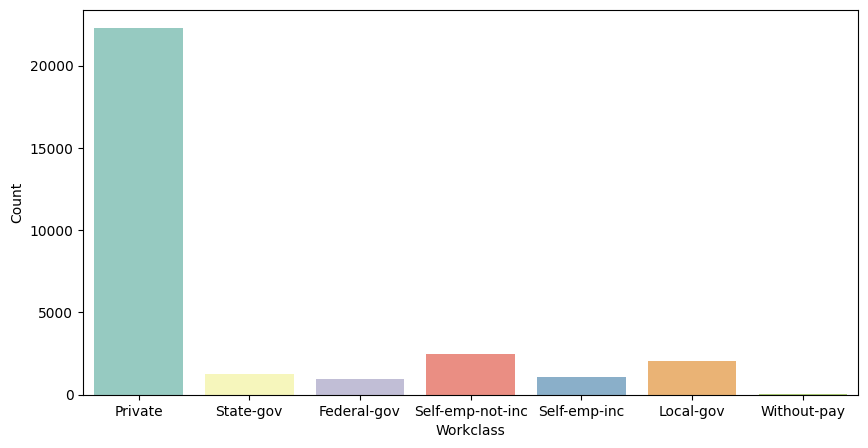

In [21]:
### Workclass
plt.figure(figsize=(10,5))
sb.countplot(x='workclass', data=df, palette="Set3")
plt.xticks(rotation=0)
plt.ylabel("Count")
plt.xlabel("Workclass")
plt.show()

Observation :

Through this Countplot, we can state that more no. of Individual are mainly in Private work category. Then Self employee, etc.
There are 7 unique categories present in the workclass attribute.

C:\Users\Asus\AppData\Local\Temp\ipykernel_14548\80222824.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sb.countplot(x='education', data=df, palette="Set3")


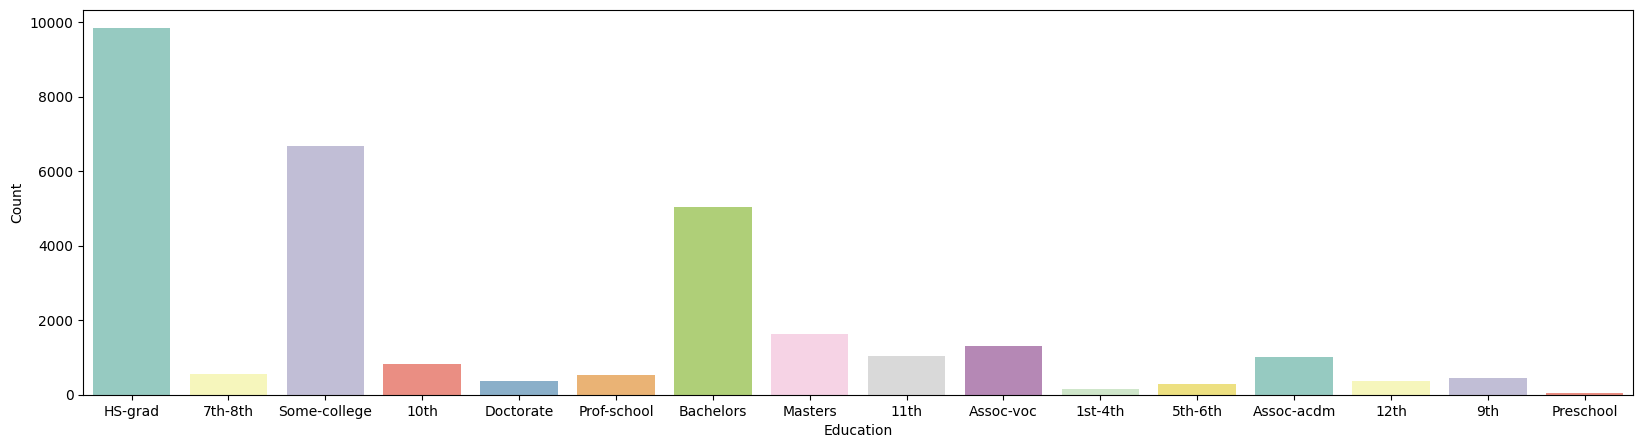

In [22]:
### Education 
plt.figure(figsize=(20,5))
sb.countplot(x='education', data=df, palette="Set3")
plt.xticks(rotation=0)
plt.ylabel("Count")
plt.xlabel("Education")
plt.show()


Observation :


Through this Countplot, we can state that the Individual's highest education degree is HS-grad which is most of them (Individual's) got followed by others Degree like Some-college, Bachelors, etc.
    There are 16 unique categories present in the education attribute.

C:\Users\Asus\AppData\Local\Temp\ipykernel_14548\488876723.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sb.countplot(x='marital.status', data=df, palette="Set3")


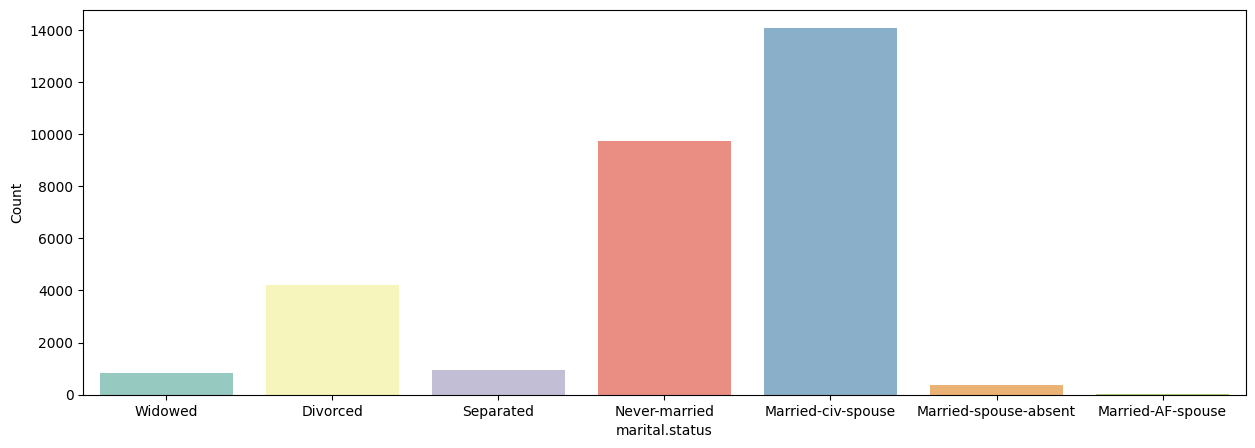

In [23]:
#marital status
plt.figure(figsize=(15,5))
sb.countplot(x='marital.status', data=df, palette="Set3")
plt.xticks(rotation=0)
plt.ylabel("Count")
plt.xlabel("marital.status")
plt.show()

Observation :

Through this graph we state that for Individual marital status, the Married-civ-spouse are more than others which is followes by those Never married, Divorced marital, etc.
There are maximum number of observation in Married-civ-spouse.
There are minimum number of observation in Married-AF-spouse.
This marital.status attribute has 7 unique categories.

C:\Users\Asus\AppData\Local\Temp\ipykernel_14548\308572952.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sb.countplot(x='occupation', data=df, palette="Set3")


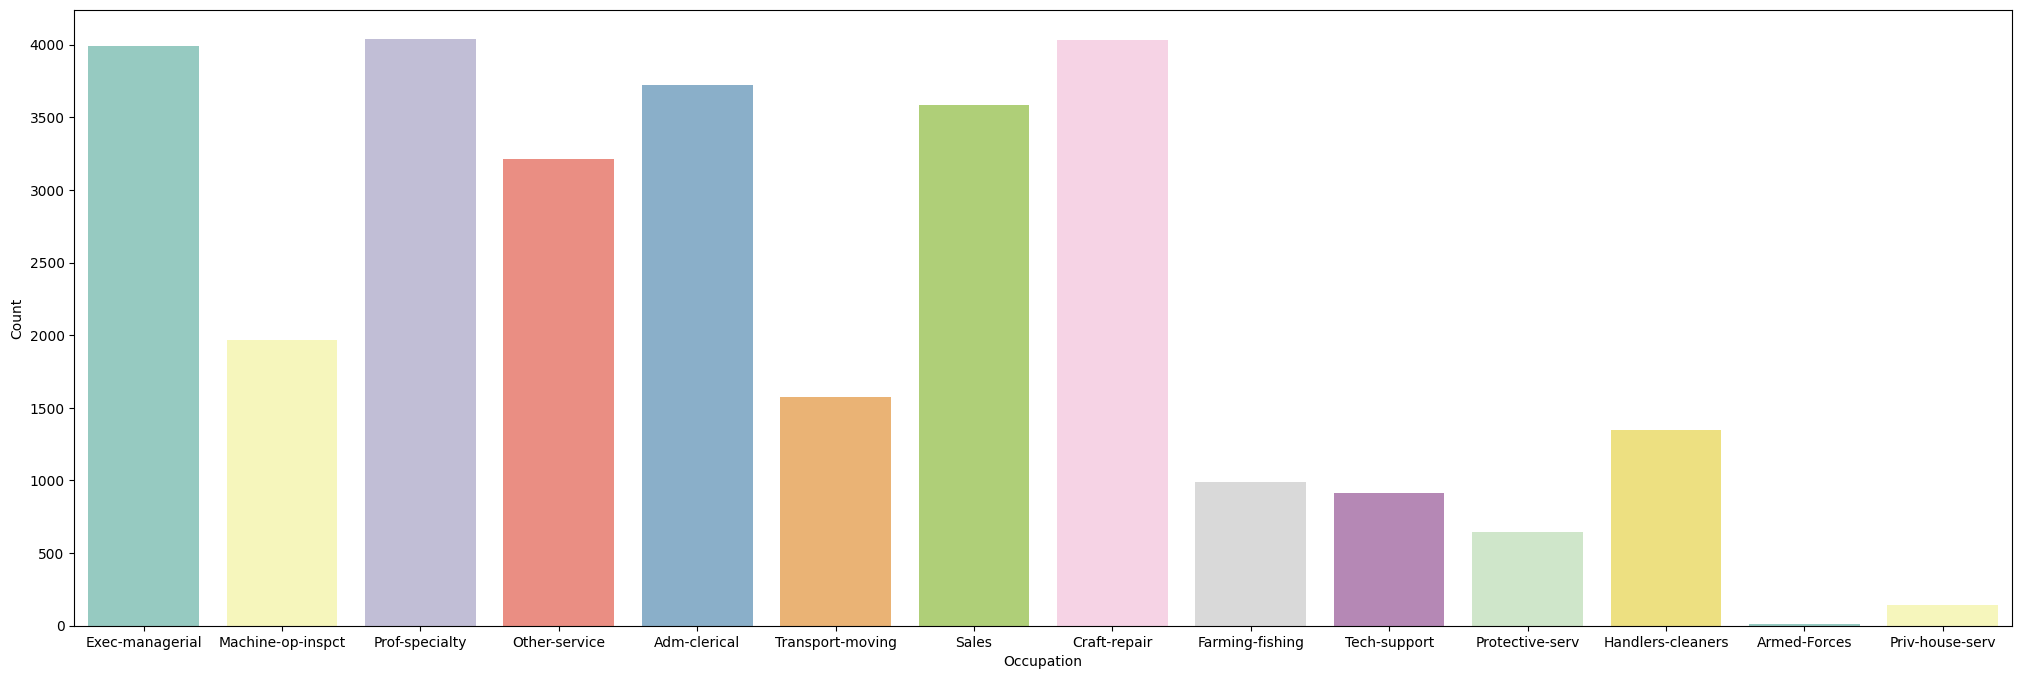

In [24]:
### Occupation
plt.figure(figsize=(25,8))
sb.countplot(x='occupation', data=df, palette="Set3")
plt.xticks(rotation=0)
plt.ylabel("Count")
plt.xlabel("Occupation")
plt.show()

Observation :

Through this Countplot we can state that the occupation of Individual's are more in Prof. specialty, then followed by Craft repair, Adm clerical and rest other occupations.
Or we can say 'Prof-specialty' has the maximum samples in the occupation attribute and on the other hand 'Armed-Forces' has minimum samples in the occupation attribute.
There are 14 unique categories present in the occupation attribute.

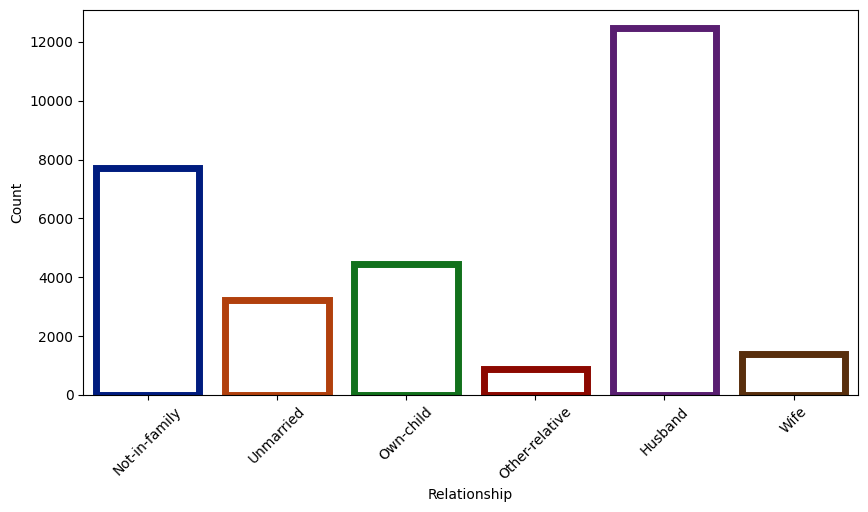

In [25]:
### Relationship
plt.figure(figsize=(10,5))

sb.countplot(
    x='relationship',
    data=df,
    facecolor=(0, 0, 0, 0),   # blank inside
    linewidth=5,             # thick border
    edgecolor=sb.color_palette("dark", 6)  # same dark palette
)

plt.xticks(rotation=45)
plt.ylabel("Count")
plt.xlabel("Relationship")

plt.show()


Observation :

Through this Countplot we can state that the Individual's relation in a family are more with Husband, and then followed by that have no relationship with family and other relationships.
There are 6 unique categories in the relationship attribute.

C:\Users\Asus\AppData\Local\Temp\ipykernel_14548\3411046510.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sb.countplot(x='race', data=df, palette="Set3")


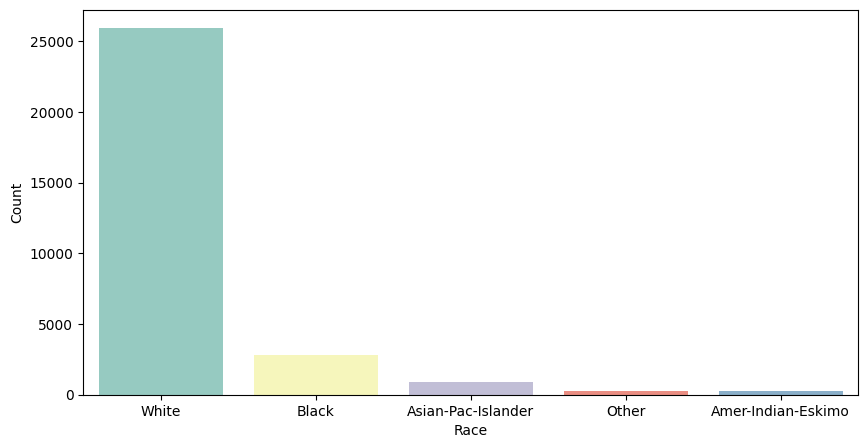

In [26]:
### Race
plt.figure(figsize=(10,5))
sb.countplot(x='race', data=df, palette="Set3")
plt.xticks(rotation=0)
plt.ylabel("Count")
plt.xlabel("Race")
plt.show()

Observation :

Through this Countplot, we can state that in Race of Individual there are more White person, then others.
There are 5 unique categories in the race attribute.

C:\Users\Asus\AppData\Local\Temp\ipykernel_14548\3531556891.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sb.countplot(


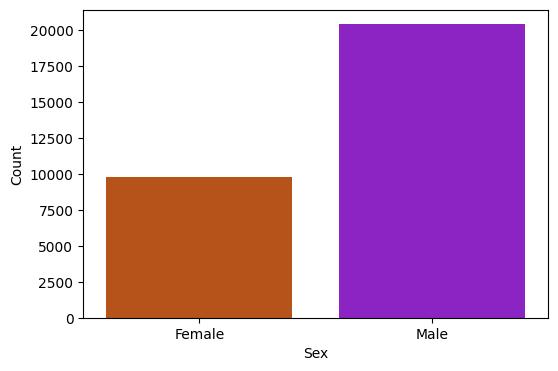

In [27]:
###sex
plt.figure(figsize=(6,4))

sb.countplot(
    x='sex',        # X-axis
    y=None,         # Y-axis automatically becomes count
    data=df,
    palette="gnuplot_r"
)

plt.xlabel("Sex")
plt.ylabel("Count")

plt.show()


Observation :

Through this Countplot we can say there is more Male Individual's then Female. We can also go above where we analyzed that there are 67% of Male and 33% of Female.
Sex column has 2 unique categories Male and Female .

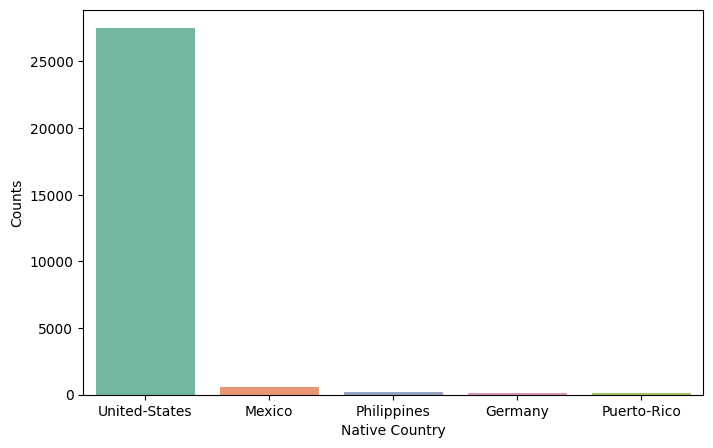

In [28]:
### Native Country
plt.figure(figsize=(8,5))

top_countries = (
    df['native.country']
    .value_counts()
    .head(5)
    .reset_index()
)

top_countries.columns = ['native.country', 'counts']

sb.barplot(
    x='native.country',
    y='counts',
    data=top_countries,
    palette='Set2',                 # different colors
    hue='native.country',           # required for palette
    legend=False
)

plt.xticks(rotation=0)
plt.xlabel("Native Country")
plt.ylabel("Counts")

plt.show()


In [29]:
df['native.country'].value_counts().head()

native.country
United-States    27504
Mexico             610
Philippines        188
Germany            128
Puerto-Rico        109
Name: count, dtype: int64

Observation :

Through this graph we can state that Individual's native country are more United States(27504). And this also can be seen through the above analysis where mostly Individual's native country is United States.
There are 41 unique categories present in the 'native.country' attribute. But due to alot of variable we have taken 5 varaibles to show in Countplot.

-- Pie chart :

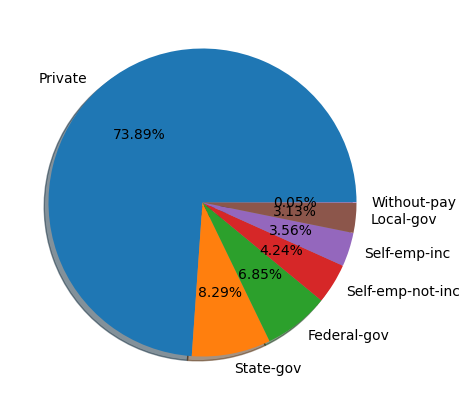

In [30]:
### workclass 
plt.figure(figsize=(10,5))
plt.pie(df["workclass"].value_counts(),autopct='%.2f%%', shadow=True,labels=df.workclass.unique())
plt.show()

Observation :

Through this Percentage distrubution of Workclass, we can state that 73.89% of Individual's or Majority of Individual's work in Private sector. 

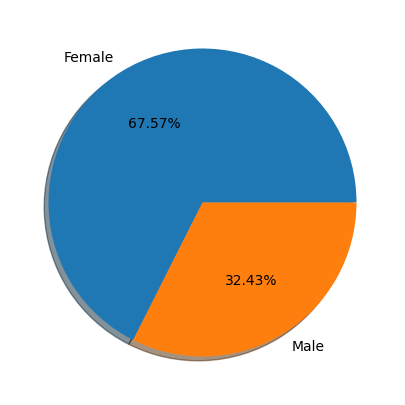

In [31]:
### Sex
plt.figure(figsize=(10,5))
plt.pie(df["sex"].value_counts(),autopct='%.2f%%', shadow=True,labels=df.sex.unique())
plt.show()

Observation :

Through this Piechart for Percentage distribution of sex column we can state that 67.57% of Individual's are Male and 32.43% of Individual's are Female. 

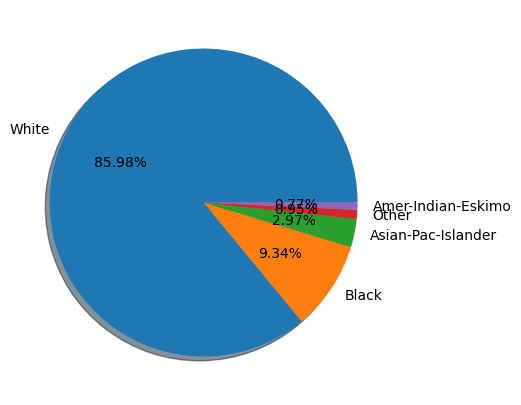

In [32]:
### Race
plt.figure(figsize=(10,5))
plt.pie(df["race"].value_counts(),autopct='%.2f%%', shadow=True,labels=df.race.unique())
plt.show()

Observation :

Through this Percentage distrubution for Race, we can state that 85.98% are White.

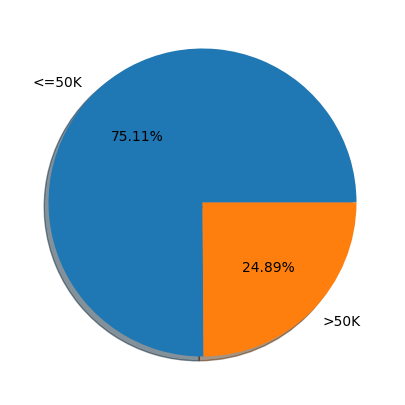

In [33]:
### income
plt.figure(figsize=(10,5))
plt.pie(df["income"].value_counts(),autopct='%.2f%%', shadow=True,labels=df.income.unique())
plt.show()

Observation :

In this the chart we can say 75.11% of them are belong to income group who earns less than 50k (or <=50K) and 24.89% fall under the income group who earns more than 50k (or >50K).

-- Histogram :

C:\Users\Asus\AppData\Local\Temp\ipykernel_14548\2173035422.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sb.distplot(df['age'], rug=True)


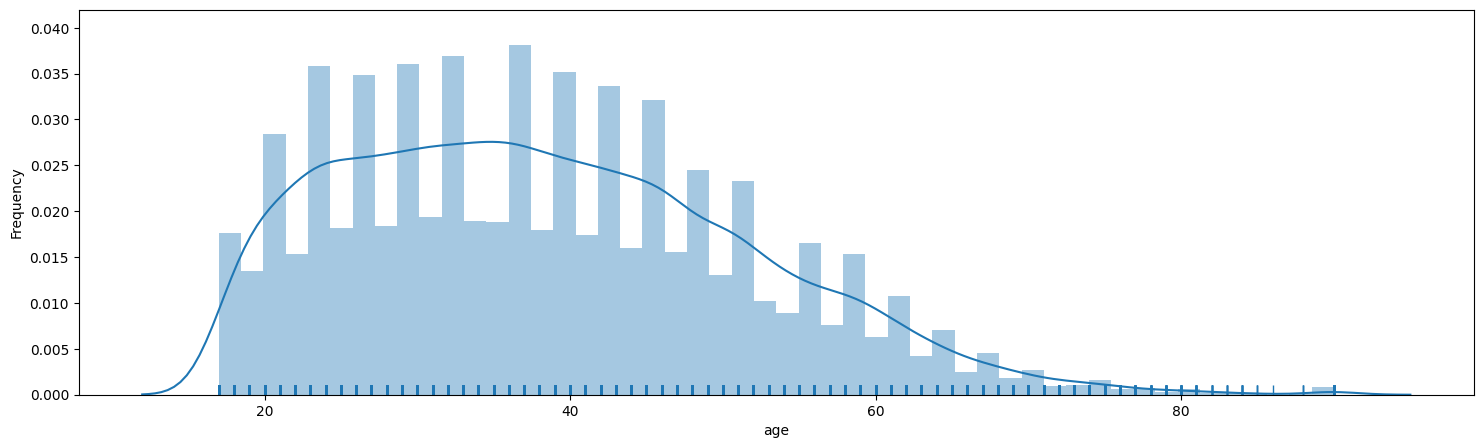

In [34]:
### Age
plt.figure(figsize=(18,5))
plt.ylabel('Frequency')
plt.xlabel('Age')
sb.distplot(df['age'], rug=True)
plt.show()

Observation :

"age" attribute is not symmetric.
Above graph is right-skewed.
Minimum and Maximum age of the people is 17 and 90 respectively.
Through this Histogram we can say that Age of an Individual is more in between 22 and 38. And maximum age is approx. 36 or 37. And the Frequency of Age is more at Age of approx. 37 .

C:\Users\Asus\AppData\Local\Temp\ipykernel_14548\716945838.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sb.distplot(df['education.num'], rug=True)


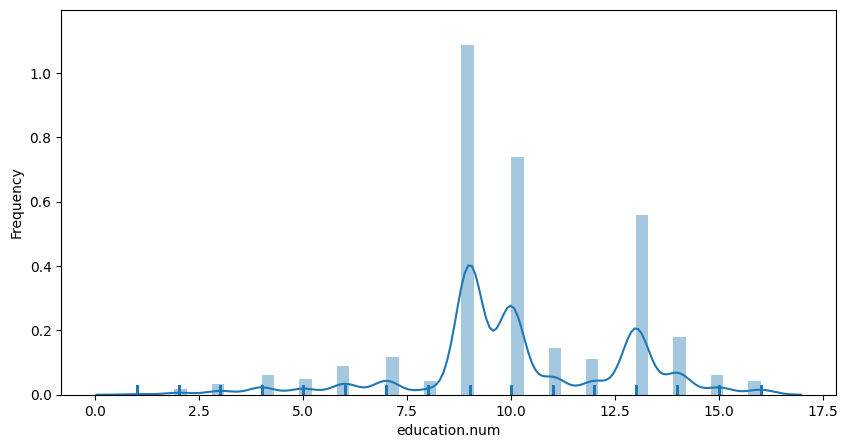

In [35]:
### Educational.num : Number of Education Year
plt.figure(figsize=(10,5))
plt.ylabel('Frequency')
plt.xlabel('Education.num')
sb.distplot(df['education.num'], rug=True)
plt.show()

Observation :

Through this graph we can state that the Individual's year of receiving education is more in 9th. And the frequency is greater in year of 9th.

C:\Users\Asus\AppData\Local\Temp\ipykernel_14548\170973868.py:6: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sb.distplot(df['capital.gain'], kde_kws={'bw':0.1})
c:\Users\Asus\Data-Analysis-Projects\env\Lib\site-packages\seaborn\distributions.py:2496: UserWarning: 

The `bw` parameter is deprecated in favor of `bw_method` and `bw_adjust`.
Setting `bw_method=0.1`, but please see the docs for the new parameters
and update your code. This will become an error in seaborn v0.14.0.

  kdeplot(**{axis: a}, ax=ax, color=kde_color, **kde_kws)
C:\Users\Asus\AppData\Local\Temp\ipykernel_14548\170973868.py:10: UserWarning: 

`distplot` is a deprecated function and

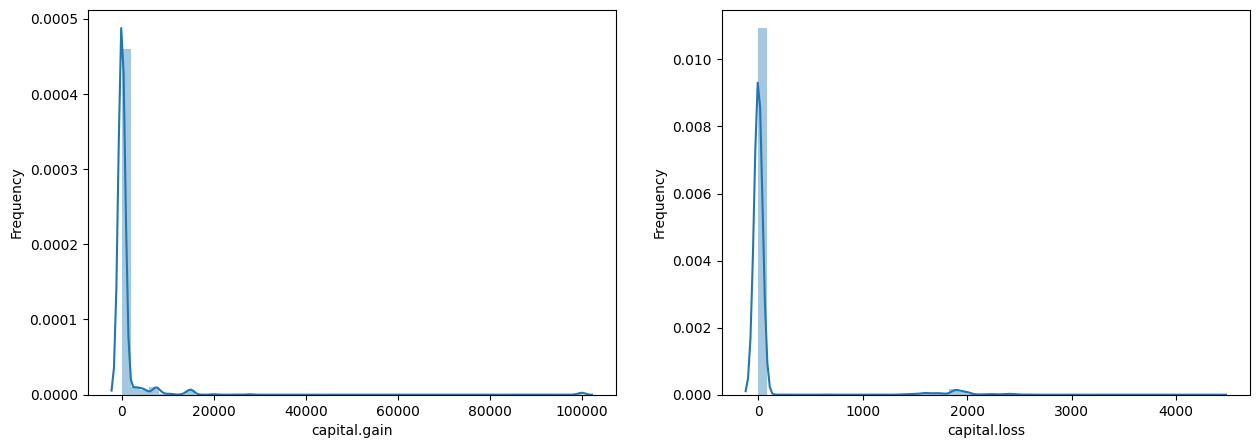

In [36]:
### Capital Gain
plt.figure(figsize=(15,5))
plt.subplot(121)
plt.ylabel('Frequency')
plt.xlabel('capital.gain')
sb.distplot(df['capital.gain'], kde_kws={'bw':0.1})
plt.subplot(122)
plt.ylabel('Frequency')
plt.xlabel('capital.loss')
sb.distplot(df['capital.loss'],kde_kws={'bw':0.1})
plt.show()

Observation:

Through this 1st graph we can state that there are many Individuals with no Captial gain or profit.
'capital-gain' shows that either a person has no gain or has gain of very large amount
2nd Histogram we can say that for most of the Individuals there is no financial loss/captial loss.

C:\Users\Asus\AppData\Local\Temp\ipykernel_14548\841652341.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sb.distplot(df['hours.per.week'])


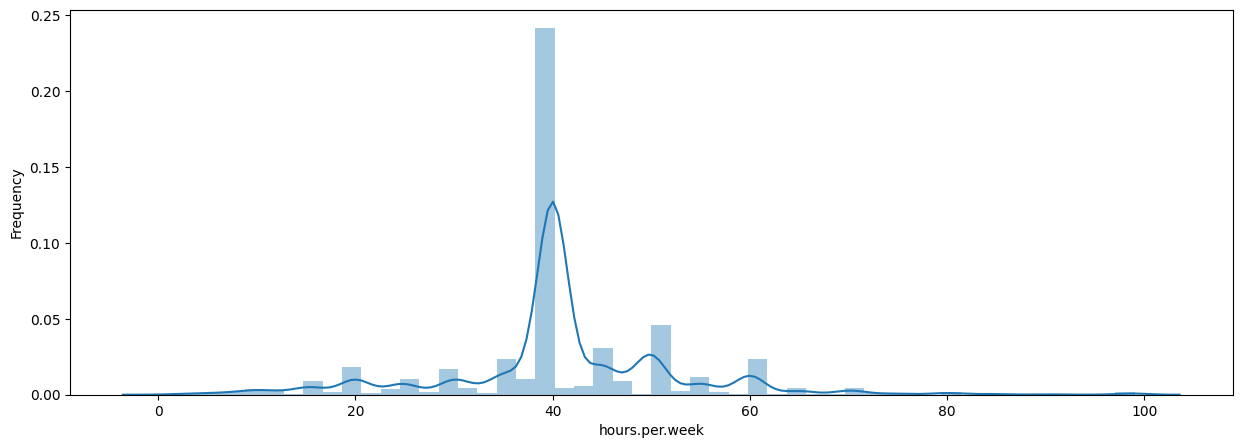

In [37]:
### Hours per week 
plt.figure(figsize=(15,5))
plt.ylabel('Frequency')
plt.xlabel('hours.per.week')
sb.distplot(df['hours.per.week'])
plt.show()



Observation :

In this data the hours per week atrribute varies within the range of 1 to 99.
Through this plot we can state that more Individual's working around 40 hour per week. And Highest hours per week is 40 hrs/week.
There are also few people who works 80-100 hours per week and some less than 20 which is unusual.

-- Boxplot :

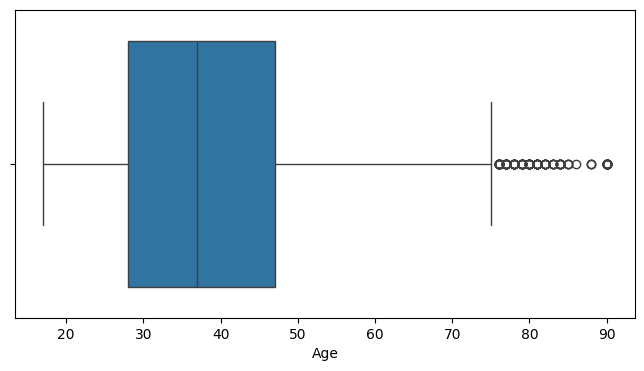

In [38]:
### Age
plt.figure(figsize=(8,4))
sb.boxplot(
    x='age',
    data=df
)
plt.xlabel("Age")
plt.show()

Observation:

Through this Boxplot we can say that the median of 'age' is 37. In Age plot after Highest obeservation (78) there are some outliers between age of 78 and 90. Range is 20.

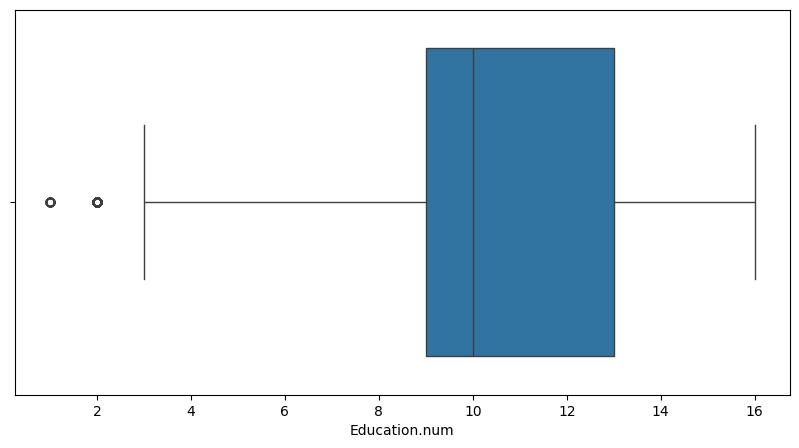

In [39]:
### Educational num
plt.figure(figsize=(10,5))
sb.boxplot(x='education.num', data=df)
plt.xlabel("Education.num")
plt.show()

Observation :

The majority of density of Education is lie between 5 and 16 .
There are less Outliers.

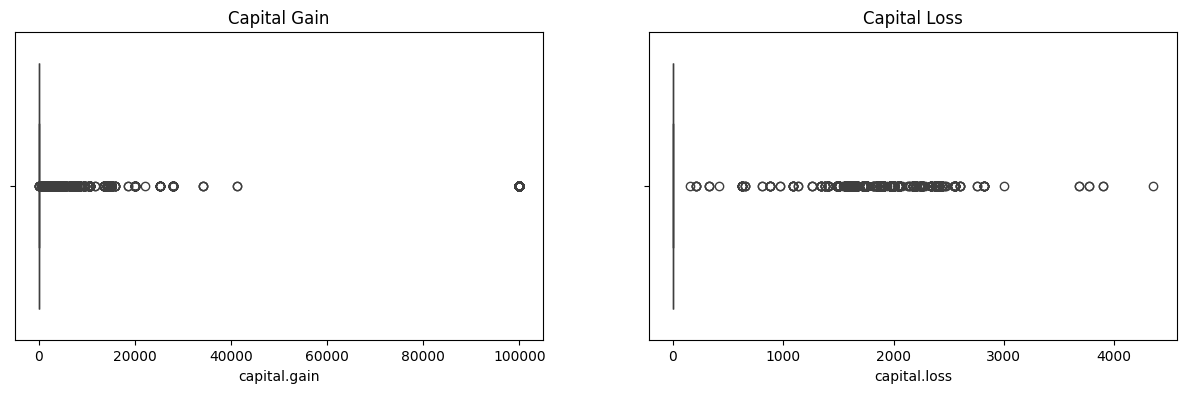

In [40]:
### Capital Gain
plt.figure(figsize=(15, 4))
plt.subplot(121)
sb.boxplot(x='capital.gain', data=df)
plt.title('Capital Gain')
plt.subplot(122)
sb.boxplot(x='capital.loss', data=df)
plt.title('Capital Loss')
x = df['capital.loss'].describe()
plt.show()

Observation :

Through this Boxplot we can say there is less no. of Individuals those who are getting Profit or Loss.
There is Majority of Outliers.
Through this we can also state that both capital gain and capital loss can be zero.

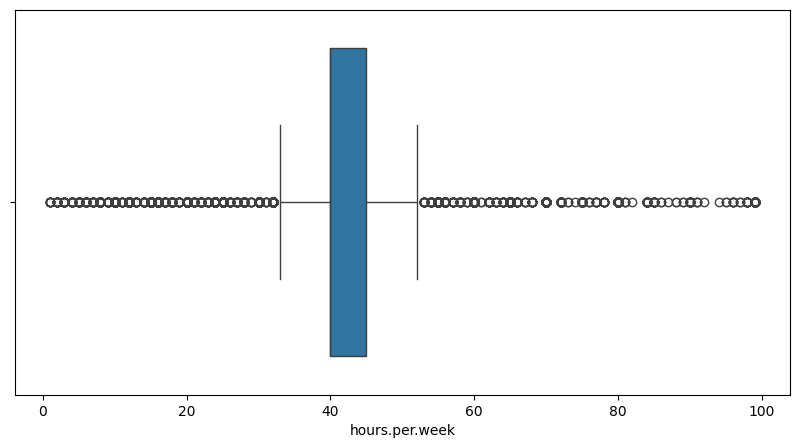

In [41]:
### Hours Per Week
plt.figure(figsize=(10,5))
sb.boxplot(x='hours.per.week', data=df)
plt.show()



Observation :

Through this Boxplot we can state that most of Individuals work between 35 - 55 hours per week.

-- PDF (Probability Distribution Function) 

C:\Users\Asus\AppData\Local\Temp\ipykernel_14548\3942479857.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sb.distplot(df['age'],hist = False,kde=True)


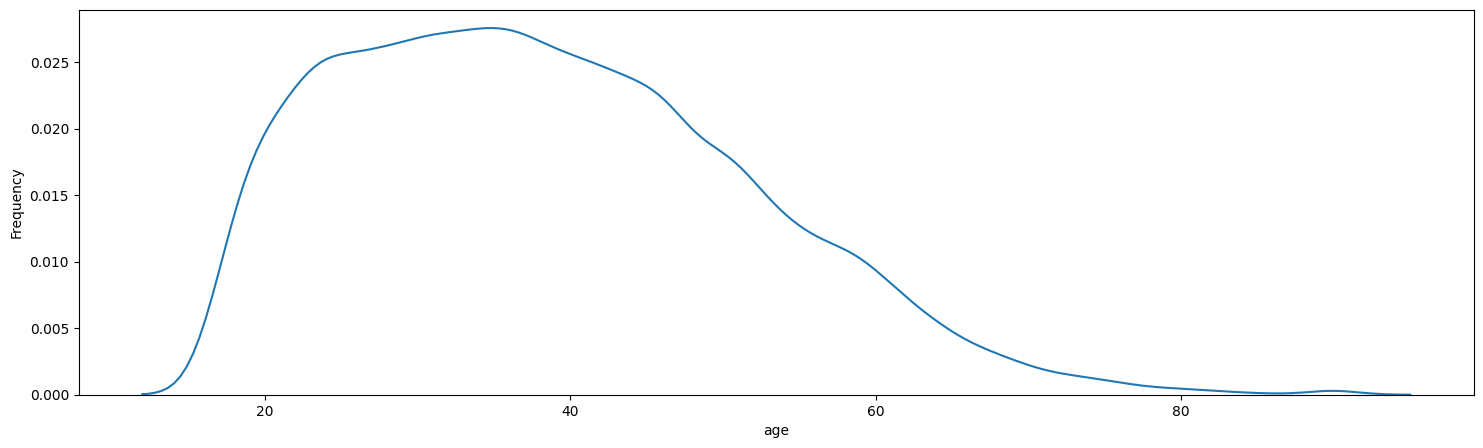

In [42]:
### Age
plt.figure(figsize=(18,5))
plt.ylabel('Frequency')
plt.xlabel('Age')
sb.distplot(df['age'],hist = False,kde=True)
plt.show()



Observation :

Through this P. dist. graph the results say that "age" attribute is not symmetric.
Minimum and Maximum age of the people is 17 and 90 respectively.

C:\Users\Asus\AppData\Local\Temp\ipykernel_14548\281303420.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sb.distplot(df['education.num'], hist=False, rug=True)


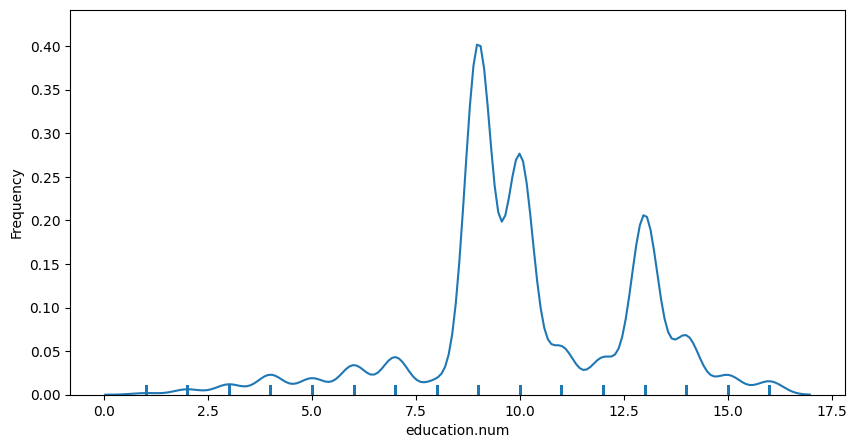

In [43]:
### Educational-num : Number of Education Year
plt.figure(figsize=(10,5))
plt.ylabel('Frequency')
plt.xlabel('Education.num')
sb.distplot(df['education.num'], hist=False, rug=True)
plt.show()

Observation:

Through this distplot we can state highest frequency is between individual's year of receiving education is between 8-9 .

(B) Bivariate Analysis 

-- Scatter Plot :

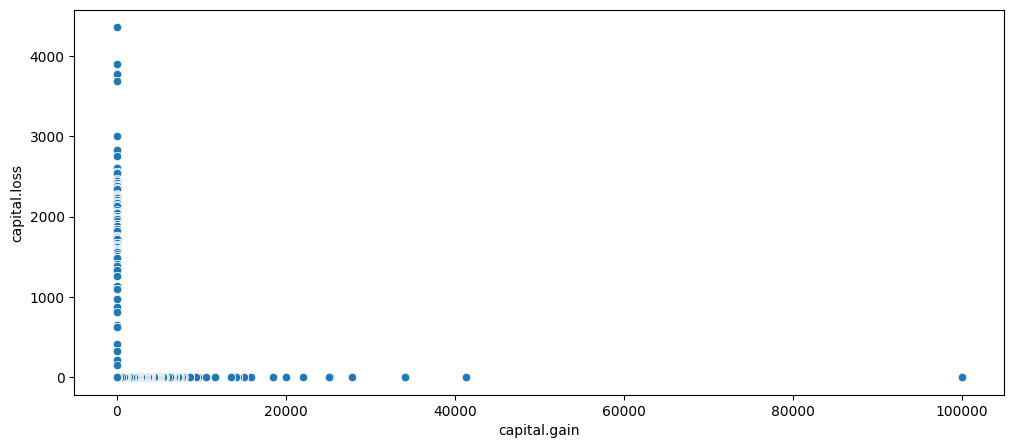

In [44]:
### Between Capital Gain and Capital Loss
plt.figure(figsize=(12,5))
sb.scatterplot(x = df['capital.gain'], y = df['capital.loss'])
plt.show()

Observation :

Through this graph we can state that Both capital gain and capital loss can be zero.
We can also conclude through above analysis that has been done that, If Capital Gain is zero there is possibility of capital loss being high or above zero vise-versa; if Capital Loss is zero there is possibility of Capital gain being above zero or high.

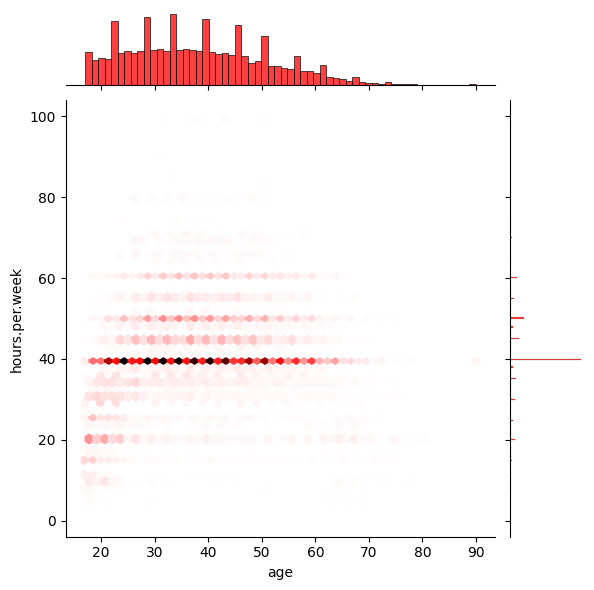

In [45]:
sb.jointplot(x='age', y='hours.per.week',kind= 'hex', data=df, color='r')
plt.show()

Observation :

Through this plot we can state the density is mainly between 40 - 60 hours per week where the age density is between 20 to 65 year of age.

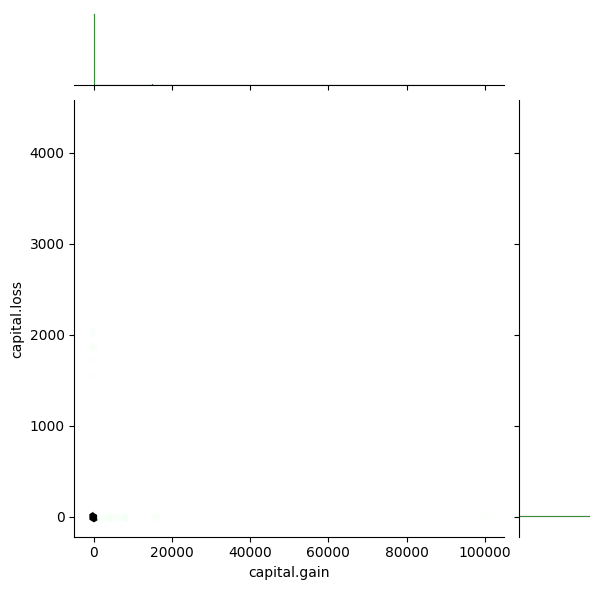

In [46]:
sb.jointplot(x='capital.gain', y='capital.loss', data=df, kind='hex', color='g')
plt.show()

Observation:

Through this plot we can say mainly of density lie at point 0 .

-- Boxplot :

In [47]:
df.groupby(['income']).mean(numeric_only=True)

,age,education.num,capital.gain,capital.loss,hours.per.week
income,,,,,
<=50K,36.60806,9.629116,148.893838,53.448000,39.348592
>50K,43.95911,11.606420,3937.679808,193.750666,45.706580


In [48]:
df.groupby(['income']).median(numeric_only=True)

,age,education.num,capital.gain,capital.loss,hours.per.week
income,,,,,
<=50K,34.0,9.0,0.0,0.0,40.0
>50K,43.0,12.0,0.0,0.0,40.0


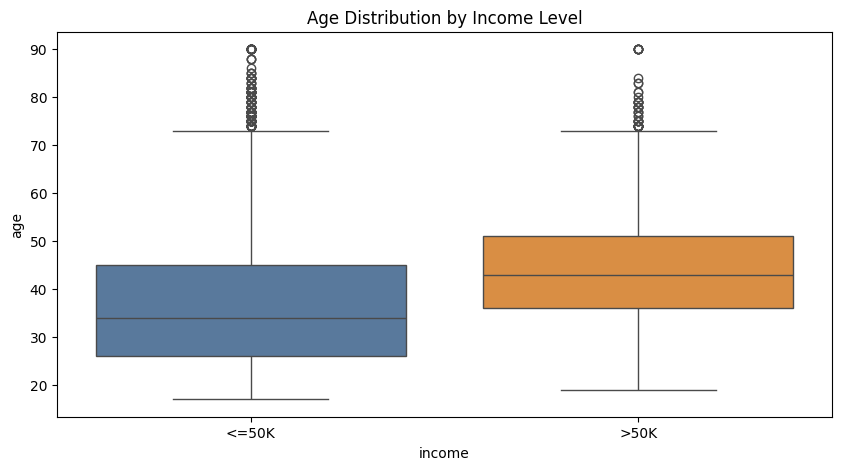

In [49]:
### Age (Relationship with income)
fig = plt.figure(figsize=(10,5)) 
my_colors = ["#4e79a7", "#f28e2b"] 

sb.boxplot(x="income", y="age", data=df, palette=my_colors, hue="income", legend=False)
plt.title("Age Distribution by Income Level")
plt.show()

Observation :

Through this bivarite analysis between Age and income we can say the income group(<=50k) has median of age 34 year which lower than the income group(>50k) which has median of age 43 year .
Outliers present in both the income group w.r.t. "age" attribute.
For income group(<=50k) Interquartile range (IQR) is between 25 & 46 . And on the other hand for income group(>50k) the IQR is between 38 & 50 .

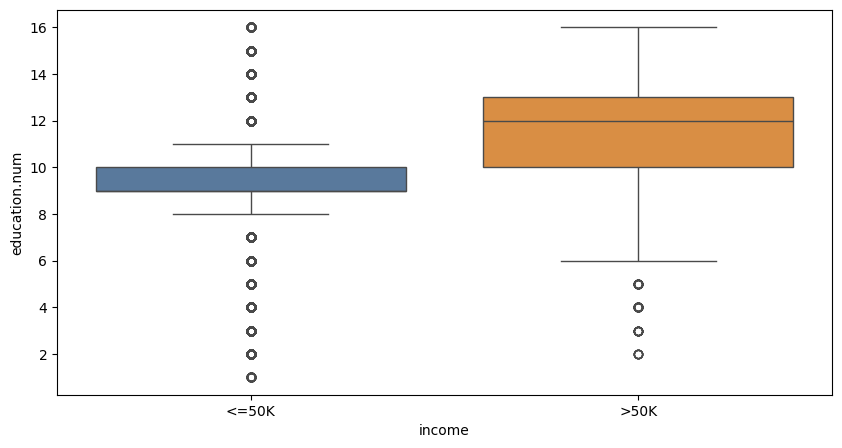

In [50]:
### educational-num (Relationship with income)
fig = plt.figure(figsize=(10,5)) 
my_colors = ["#4e79a7", "#f28e2b"]
sb.boxplot(x="income", y="education.num",palette=my_colors,hue="income",legend=False,data=df)
plt.show()

Observation :

Through this analysis between education.num and income we can say the income group(<=50k) has median of 9 year i.e. year of receiving education which lower than the income group(>50k) which has median of 12 year of receiving education.
Outliers present in both the income group w.r.t. "education.num" attribute, where we can say the income group(<=) has more outliers than group (>50k).
For income group(<=50k) Interquartile range (IQR) is between 9 & 10 . And on the other hand for income group(>50k) the IQR is between 10 & 13 .

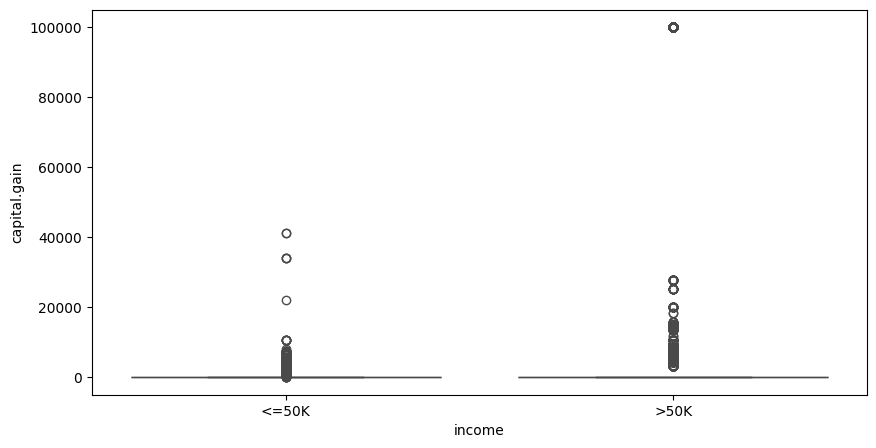

In [51]:
### Captial Gain (Relationship with income)
fig = plt.figure(figsize=(10,5)) 
my_colors = ["#4e79a7", "#f28e2b"]
sb.boxplot(x="income", y="capital.gain", data=df, palette=my_colors, hue="income", legend=False)
plt.show()

Observation :

Through this plot we can state that most of the capital gains value is accumulated at 0 for both the income group (<=50k and >50k) .
Both income group have Outliers w.r.t. to 'captial.gain' attribute.

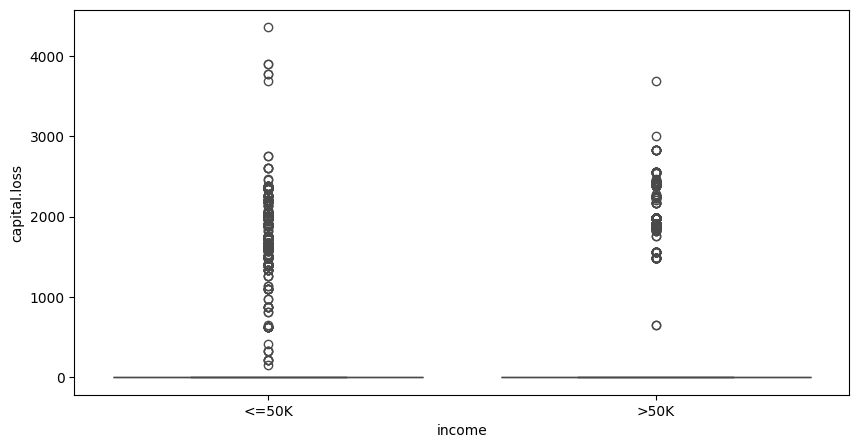

In [52]:
### Captial Loss (Relationship with income)
fig = plt.figure(figsize=(10,5)) 
my_colors = ["#4e79a7", "#f28e2b"]
sb.boxplot(x="income", y="capital.loss", data=df, palette=my_colors, hue="income", legend=False)
plt.show()

Observation :

Through above analys we can say this boxplot is similar to the capital gain boxplot where most of the values are concentrated on 0.
Both income group have Outliers w.r.t. to 'captial.loss' attribute.

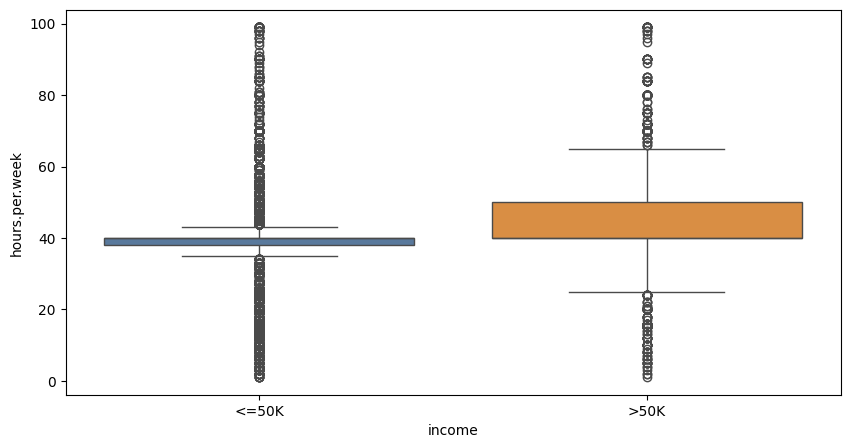

In [53]:
### Hours per Week (Relationship with income)
fig = plt.figure(figsize=(10,5)) 
my_colors = ["#4e79a7", "#f28e2b"]
sb.boxplot(x="income", y="hours.per.week", data=df, palette=my_colors, hue="income", legend=False)
plt.show()

Observation :

Through this bivarite analysis between and income we can say the Median of "hours.per.week" for income group who earns >50k is greater than the income group who earns <=50k.
Outliers present in both the income group w.r.t. "age" attribute. But more Outliers present in the income group who earns <=50k.
For those income group who earns >50k has spend approx 45 hours per week than for those income group who earns <=50k has spend approx 38 hours per week.
It means that hours per week has some contribution to the distinguish income groups.

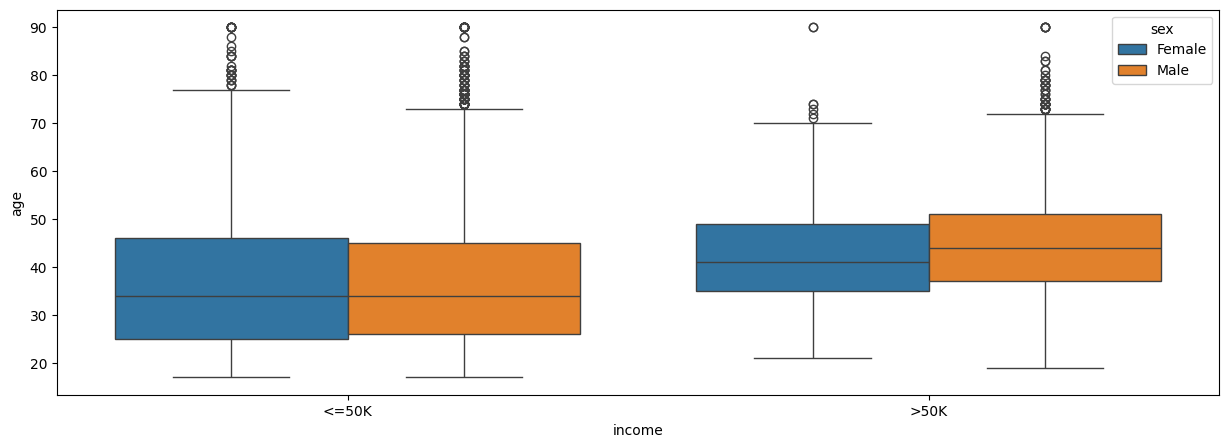

In [54]:
plt.figure(figsize=(15,5))
sb.boxplot(x="income", y="age",hue="sex",data=df)
plt.show()

Observation :

Through this Boxplot we can say more age of Indivials earns more than 50K. and more female under less range of age earns less than 50K.
There are many Outliers in both the income group in upper end.
There is a relationship between sex and income.

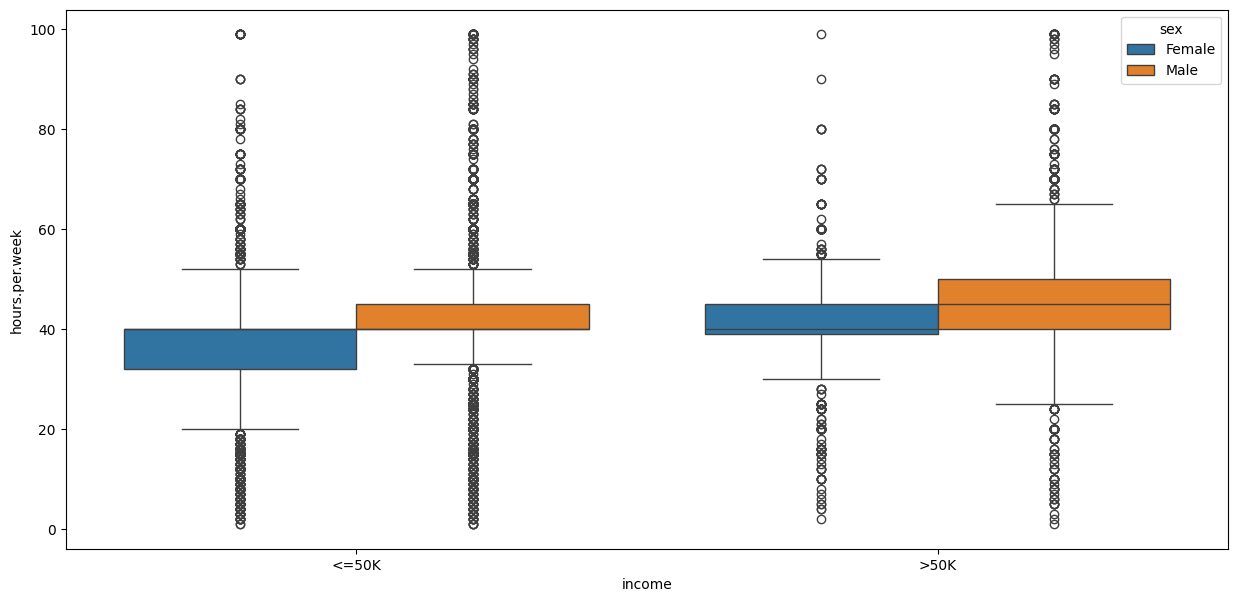

In [55]:
plt.figure(figsize=(15,7))
sb.boxplot(x="income", y="hours.per.week",hue="sex",data=df)
plt.show()

Observation :

Through this Boxplot we can conclude that mostly Male sex gender works most of the hours per week than female. Then Individual's who working more hours per week earning mostly.
We can see the outliers in both the ends.

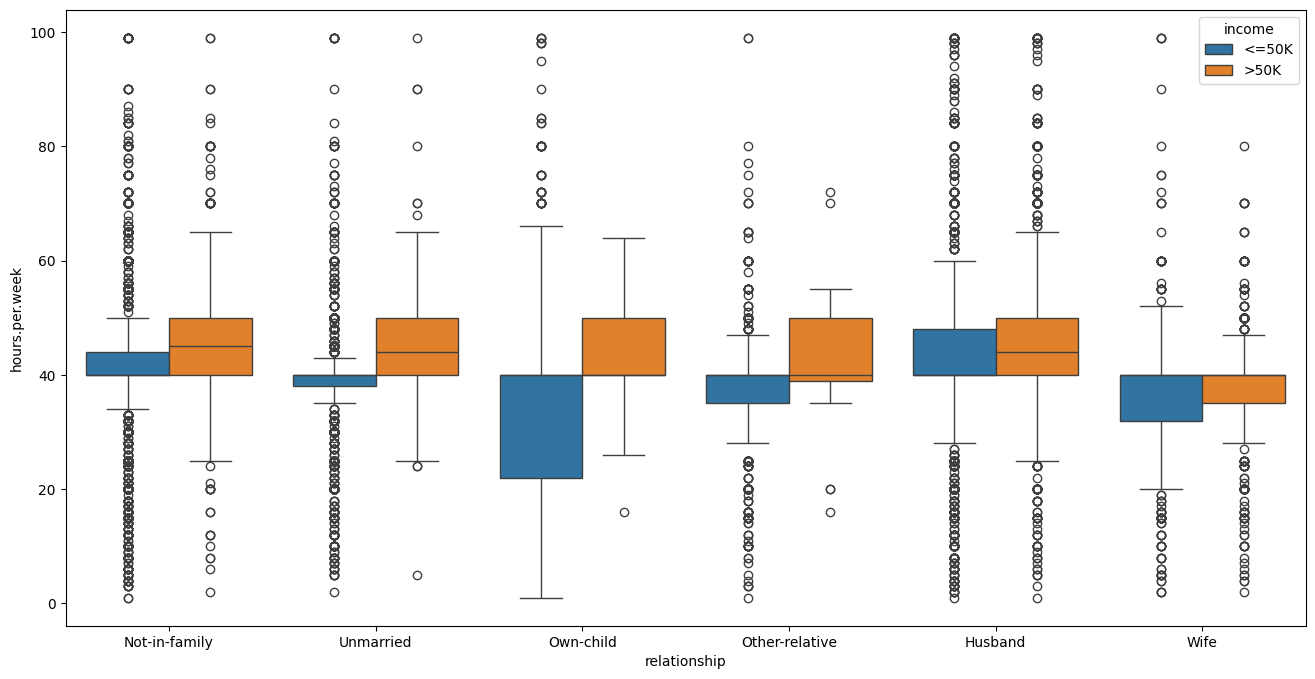

In [56]:
plt.subplots(figsize=(16, 8))  
sb.boxplot(x='relationship', y='hours.per.week', hue='income', data=df)  
plt.show() 


Observation :

From the above Boxplot we got some interesting results i.e., Individual with the some relationship status and with income group >50K (more than 50k) often work for more hours per week.
We can see the outliers in the data. Individuals with relationship status ‘Not-in-family’ and income group <=50k have a large number of outliers at both the ends.

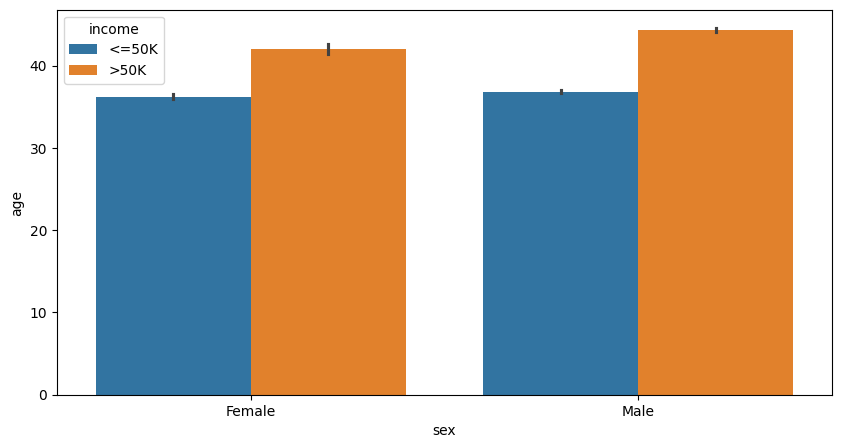

In [57]:
plt.figure(figsize=(10,5))
sb.barplot(x="sex", y="age", hue="income", data=df)
plt.show()

Observation :

Through this barplot we can say that in both group of sex gender (Male and Female) the Individual income are have more in 50K (>50K)

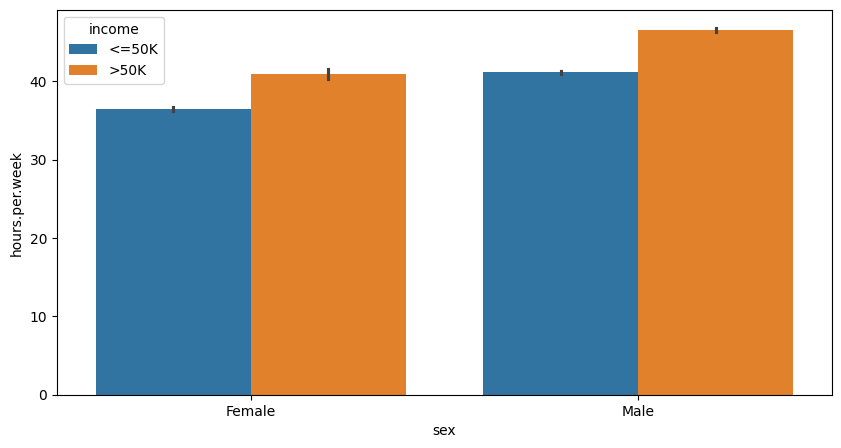

In [58]:
plt.figure(figsize=(10,5))
sb.barplot(x="sex", y="hours.per.week", hue="income", data=df)
plt.show()

Observation :

We can observe through above barplot that Males have more flexible working hours per week in the income groups who earns >50k. 

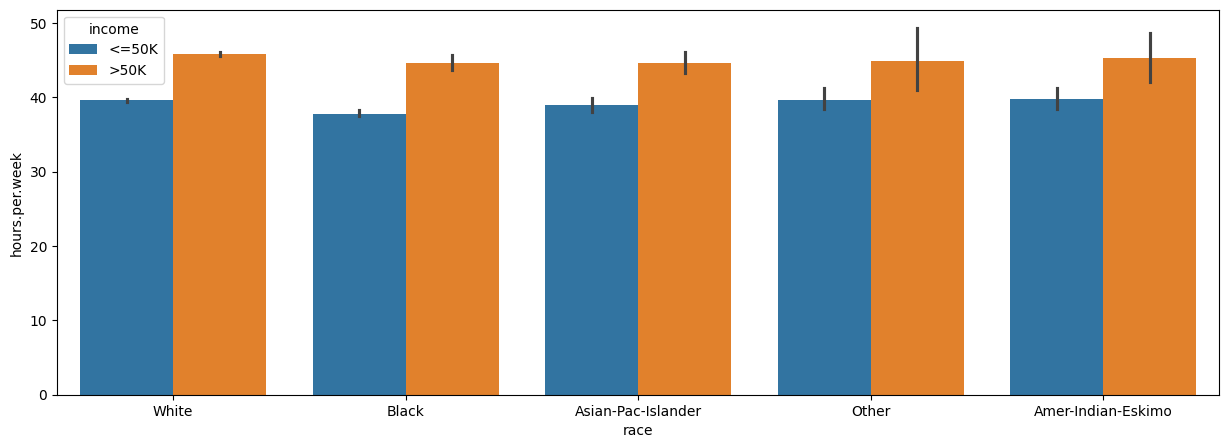

In [59]:
plt.figure(figsize=(15,5))
sb.barplot(x="race", y="hours.per.week", hue="income", data=df)
plt.show()

Observation :

White people are earning more income and working most of the hours per week.

-- Pairplot :

In [ ]:
sb.pairplot(
    df,
    hue='income',
    palette="husl",
    markers=["o", "s"],
    diag_kws={'bw_adjust': 1}
)

Observation :

The Individual of Age between ~18 to ~70 works most of the hours per week get the more paid income i.e. greater than 50.
We can also state that from Age attribute that most of the people earns greater than 50k.
Income group who earns >50k have flexible working hours.
Individual's having captial gain/profit or no profit earns grater than 50k, whereas Individual's having captial loss or no loss mostly earns lower than 50k.
Most of the Individuals more educational numbers have more income or greater than 50k.

-- Heatmap :

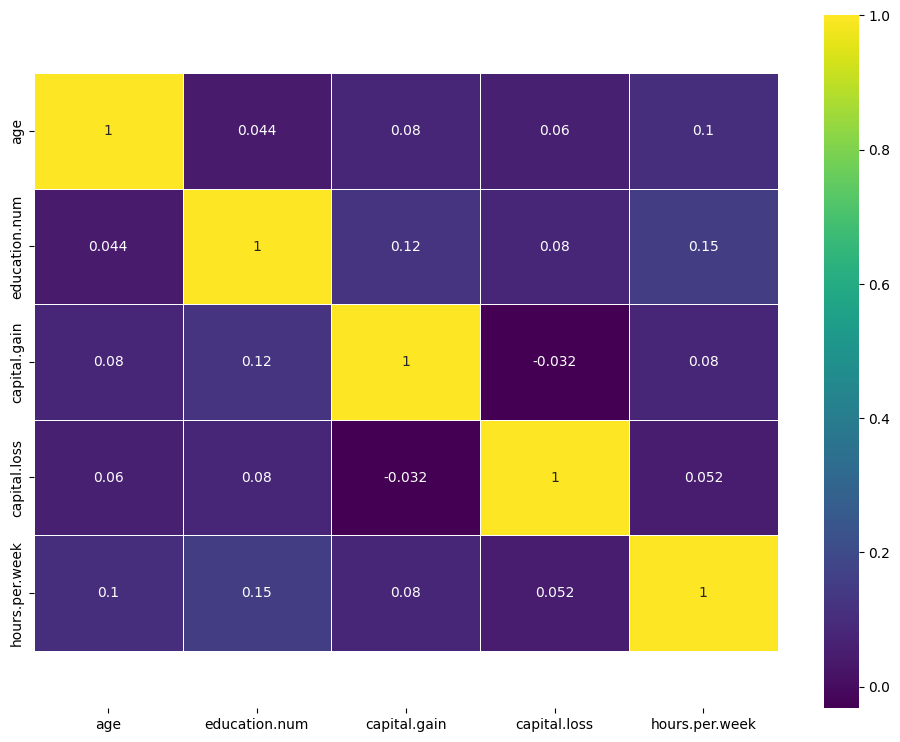

In [ ]:
t1 = df.corr(numeric_only=True)

plt.figure(figsize=(12,9))
ax = sb.heatmap(t1, linewidths=.5, annot=True, cmap="viridis")

bottom, top = ax.get_ylim()
ax.set_ylim(bottom + 0.5, top - 0.5)

plt.show()

Observation from above heatmap :

There is no strong correlation among the numeric attributes.
There is neither strong positive nor strong negative correlation present in any variable .
There is correlation present between capital gain and hours.per.week with value 0.08 

Conclusion of EDA :

Females have more flexible working hours per week in the income groups who earns <=50k. Whereas Males have more flexible working hours per week in the income groups who earns >50k.
Generally Individual's can be seen working for 30 hours to 40 hours per week.
Income group of Individuals who earns >50k have flexible working hours.
Education.num attribute is affecting the target
Captial Gain and Capital Loss attribute have most of the outliers.
Workclass and Occupation attribute have more no. of missing value that has been treated above by droping them as there were less no. of rows containing missing value in the whole dataset. So the Dataset is not affected by it.
For some of the Individuals the workclass and occuption attribute variable is missing and they are from United states. 

-- Encoding categorical features :

In [ ]:
cat = df.select_dtypes(include=['object', 'string']).copy()

In [ ]:
cat

,workclass,education,marital.status,occupation,relationship,race,sex,native.country,income
1,Private,HS-grad,Widowed,Exec-managerial,Not-in-family,White,Female,United-States,<=50K
3,Private,7th-8th,Divorced,Machine-op-inspct,Unmarried,White,Female,United-States,<=50K
4,Private,Some-college,Separated,Prof-specialty,Own-child,White,Female,United-States,<=50K
5,Private,HS-grad,Divorced,Other-service,Unmarried,White,Female,United-States,<=50K
6,Private,10th,Separated,Adm-clerical,Unmarried,White,Male,United-States,<=50K
...,...,...,...,...,...,...,...,...,...
32556,Private,Some-college,Never-married,Protective-serv,Not-in-family,White,Male,United-States,<=50K
32557,Private,Assoc-acdm,Married-civ-spouse,Tech-support,Wife,White,Female,United-States,<=50K
32558,Private,HS-grad,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,United-States,>50K
32559,Private,HS-grad,Widowed,Adm-clerical,Unmarried,White,Female,United-States,<=50K


It selects all categorical (text-based) columns from your dataframe and stores them in a new dataframe called cat.
Using OneHotEncoder each category value is converted into a new column and assigned a 1 or 0 (notation for true/false) value to the column.

In [ ]:
encoder = OneHotEncoder(drop='first', sparse_output=False)

cat_encoded = encoder.fit_transform(cat)

cat_df = pd.DataFrame(
    cat_encoded,
    columns=encoder.get_feature_names_out(cat.columns)
)

In [ ]:
cat_df

,workclass_Local-gov,workclass_Private,workclass_Self-emp-inc,workclass_Self-emp-not-inc,workclass_State-gov,workclass_Without-pay,education_11th,education_12th,education_1st-4th,education_5th-6th,...,native.country_Puerto-Rico,native.country_Scotland,native.country_South,native.country_Taiwan,native.country_Thailand,native.country_Trinadad&Tobago,native.country_United-States,native.country_Vietnam,native.country_Yugoslavia,income_>50K
0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30157,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
30158,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
30159,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
30160,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


--Standardizing numerical data

In [ ]:
num = df.select_dtypes(include=['int64'])

In [ ]:
num

,age,education.num,capital.gain,capital.loss,hours.per.week
1,82,9,0,4356,18
3,54,4,0,3900,40
4,41,10,0,3900,40
5,34,9,0,3770,45
6,38,6,0,3770,40
...,...,...,...,...,...
32556,22,10,0,0,40
32557,27,12,0,0,38
32558,40,9,0,0,40
32559,58,9,0,0,40


Using StandardScaler it Standardize features by removing the mean and scaling to unit variance

In [ ]:
scaler = StandardScaler()

num_scaled = scaler.fit_transform(num)

num_df = pd.DataFrame(
    num_scaled,
    columns=num.columns,
    index=num.index
)


In [ ]:
num_df.head()

,age,education.num,capital.gain,capital.loss,hours.per.week
1,3.316630,-0.439738,-0.147445,10.555814,-1.914161
3,1.184831,-2.400559,-0.147445,9.427915,-0.077734
4,0.195067,-0.047574,-0.147445,9.427915,-0.077734
5,-0.337883,-0.439738,-0.147445,9.106365,0.339636
6,-0.033340,-1.616231,-0.147445,9.106365,-0.077734


In [ ]:
new_df = pd.concat([num_df, cat_df], axis=1)

We are concatenating both the dataframe using Pandas function concat().

In [ ]:
new_df

,age,education.num,capital.gain,capital.loss,hours.per.week,workclass_Local-gov,workclass_Private,workclass_Self-emp-inc,workclass_Self-emp-not-inc,workclass_State-gov,...,native.country_Puerto-Rico,native.country_Scotland,native.country_South,native.country_Taiwan,native.country_Thailand,native.country_Trinadad&Tobago,native.country_United-States,native.country_Vietnam,native.country_Yugoslavia,income_>50K
1,3.316630,-0.439738,-0.147445,10.555814,-1.914161,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3,1.184831,-2.400559,-0.147445,9.427915,-0.077734,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,0.195067,-0.047574,-0.147445,9.427915,-0.077734,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
5,-0.337883,-0.439738,-0.147445,9.106365,0.339636,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
6,-0.033340,-1.616231,-0.147445,9.106365,-0.077734,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30111,NaN,NaN,NaN,NaN,NaN,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
30121,NaN,NaN,NaN,NaN,NaN,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
30141,NaN,NaN,NaN,NaN,NaN,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
30149,NaN,NaN,NaN,NaN,NaN,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


-- Train Test Split 

In [ ]:
# X = new_df.drop('income_>50K',axis=1)
Y = new_df.pop('income_>50K')
X = new_df

train_test_split is a function in Sklearn model selection for splitting data arrays into two subsets: for training data and for testing data.

In [ ]:
X_train,X_test,y_train,y_test = train_test_split(X,Y,test_size=.30,random_state=25)


Here we are taking 70% of data for training and 30% data for testing.
random_state just fix the randomness of data state which will not change.

-- Train the model on Training Data

In [ ]:
lr = LogisticRegression( max_iter=250)
lr.fit(X_train,y_train);
#model trained,to hide to box i used semicolon

-- Prediction on Test Data

In [ ]:
# Remove NaNs from test set
X_test = X_test.dropna()
y_test = y_test.loc[X_test.index]

# Now predict
y_predict = lr.predict(X_test)

y_predict

array([0., 0., 0., ..., 0., 0., 0.], shape=(8403,))

-- Model evaluation

In [ ]:
# Accuracy classification score.
accuracy_score(y_test, y_predict)

0.8425562299178865

The Accuracy Score of the model is 84.59 %

In [ ]:
confusion_matrix(y_test, y_predict)

array([[5825,  474],
       [ 849, 1255]])

A Confusion matrix is an N x N matrix used for evaluating the performance of a classification mode. For binary classification problem [ [TP, FP], [FN, TN] ].
where;

TP - True Positive,
TN - True Negative,
FP - False Positive,
FN - False Negative



In [ ]:
print(classification_report(y_test,y_predict))

              precision    recall  f1-score   support

         0.0       0.87      0.92      0.90      6299
         1.0       0.73      0.60      0.65      2104

    accuracy                           0.84      8403
   macro avg       0.80      0.76      0.78      8403
weighted avg       0.84      0.84      0.84      8403



A Classification report is used to measure the quality of predictions from a classification algorithm

Using RFE to extract the best features and applying Logistic Regression on best features:-¶

(The Recursive Feature Elimination (RFE) method works by recursively removing attributes and building a model on those attributes that remain.
It uses accuracy metric to rank the feature according to their importance.)


In [ ]:
# Make sure no NaN exists
X_train = X_train.dropna()
y_train = y_train.loc[X_train.index]

# Increase max_iter to avoid convergence issue
lr_temp = LogisticRegression(max_iter=1000, solver='lbfgs')

# Make sure selected features <= total features
rfe = RFE(estimator=lr_temp, n_features_to_select=30)

rfe.fit(X_train, y_train)

rfe;

Now we are taking best features and creating a DataFrame of them.

In [ ]:
temp_df = pd.DataFrame({'Columns' : X_train.columns, 'Included' : rfe.support_, 'Ranking' : rfe.ranking_})
temp_df

,Columns,Included,Ranking
0,age,False,60
1,education.num,False,58
2,capital.gain,True,1
3,capital.loss,False,34
4,hours.per.week,False,66
...,...,...,...
90,native.country_Thailand,False,10
91,native.country_Trinadad&Tobago,False,55
92,native.country_United-States,False,24
93,native.country_Vietnam,True,1


In [ ]:
imp_col = X_train.columns[rfe.support_]
imp_col

Index(['capital.gain', 'education_Assoc-acdm', 'education_Assoc-voc',
       'education_Bachelors', 'education_Doctorate', 'education_HS-grad',
       'education_Masters', 'education_Prof-school', 'education_Some-college',
       'marital.status_Married-AF-spouse', 'marital.status_Married-civ-spouse',
       'marital.status_Never-married', 'occupation_Exec-managerial',
       'occupation_Farming-fishing', 'occupation_Handlers-cleaners',
       'occupation_Other-service', 'occupation_Priv-house-serv',
       'relationship_Other-relative', 'relationship_Own-child',
       'relationship_Wife', 'sex_Male', 'native.country_China',
       'native.country_Columbia', 'native.country_El-Salvador',
       'native.country_Greece', 'native.country_India',
       'native.country_Mexico', 'native.country_Peru', 'native.country_South',
       'native.country_Vietnam'],
      dtype='str')

In [ ]:
X_train_new = X_train[imp_col]
X_train_new

,capital.gain,education_Assoc-acdm,education_Assoc-voc,education_Bachelors,education_Doctorate,education_HS-grad,education_Masters,education_Prof-school,education_Some-college,marital.status_Married-AF-spouse,...,sex_Male,native.country_China,native.country_Columbia,native.country_El-Salvador,native.country_Greece,native.country_India,native.country_Mexico,native.country_Peru,native.country_South,native.country_Vietnam
16986,-0.147445,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
20529,-0.147445,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
22304,-0.147445,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7535,-0.147445,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
19786,-0.147445,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26778,-0.147445,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3108,0.529419,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
28863,-0.147445,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7126,-0.147445,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Applying the best feature we will Train the model on Training Data

In [ ]:
lrn = LogisticRegression(max_iter=250)
lrn.fit(X_train_new, y_train);

Predicting the Model

In [ ]:
y_predict_new = lrn.predict(X_train_new)
y_predict_new

array([0., 0., 1., ..., 0., 0., 1.], shape=(19558,))

In [ ]:
accuracy_score(y_test, y_predict)

0.8425562299178865

Using best features we get 84.59% of accuracy score.

-- Using PCA to extract the best features

PCA is a method used to reduce number of variables in the data by extracting important one from a large data. It reduces the dimension of the data with the aim of retaining as much information as possible.
n_components : Number of components to keep.
whiten : Whitening will remove some information from the transformed signal.
explained_variance_ratio : Percentage of variance explained by each of the selected components. If n_components is not set then all components are stored and the sum of the ratios is equal to 1.0.
np.cumsum : Return the cumulative sum of the elements along a given axis.

We are Creating a Covariance Matrix and then claculating the Eigenvalues.

AR PARBONA AAJ(pca start korbo)

In [ ]:
# Make sure no NaN
X = X.dropna()

# Scale before PCA (very important)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply PCA
pca = PCA(whiten=True)
pca.fit(X_scaled)

# Cumulative explained variance
np.cumsum(pca.explained_variance_ratio_)

array([0.03160012, 0.05852624, 0.08213129, 0.10238657, 0.12128654,
       0.13877721, 0.15433159, 0.16968219, 0.18438784, 0.19878977,
       0.21233835, 0.22548412, 0.23847475, 0.25120036, 0.26385421,
       0.27628486, 0.28849975, 0.3005429 , 0.31237099, 0.32419439,
       0.33582623, 0.34742907, 0.35896344, 0.37046872, 0.38188417,
       0.39310837, 0.40427976, 0.41544874, 0.42655959, 0.43758771,
       0.44856744, 0.45952449, 0.47040103, 0.48123988, 0.49200602,
       0.50273933, 0.51341006, 0.5240589 , 0.53469817, 0.54529731,
       0.55587706, 0.56645314, 0.57700948, 0.58755362, 0.59808946,
       0.60862415, 0.61915685, 0.62968358, 0.64020241, 0.65071885,
       0.66122455, 0.67172017, 0.68220362, 0.69267534, 0.70314229,
       0.71358085, 0.72400838, 0.73439368, 0.74474075, 0.75507475,
       0.76533044, 0.77555771, 0.78575781, 0.79589639, 0.8059868 ,
       0.81605046, 0.82602035, 0.83591347, 0.84576834, 0.85558322,
       0.86530863, 0.87489209, 0.88443454, 0.89389193, 0.90317

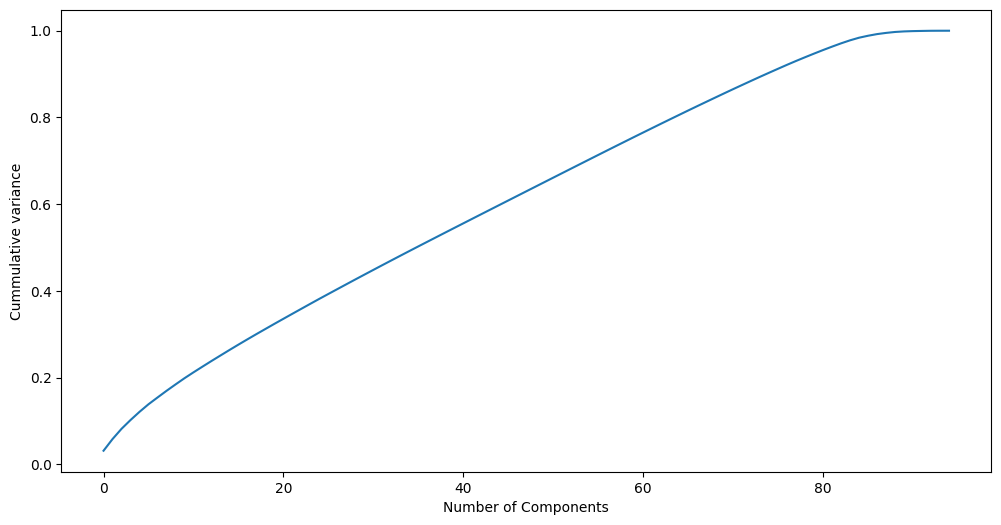

In [ ]:
plt.figure(figsize = (12, 6))
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel('Number of Components')
plt.ylabel('Cummulative variance')
plt.show()

Observation :

Based on the plot above it's clear we should pick 42 features.

In [ ]:
# Number of components = 42
pca = PCA(n_components=42,whiten=True)
X_PCA = pca.fit_transform(X)

In [ ]:
X_PCA

array([[ 2.6731013 ,  8.32307899,  2.43007088, ..., -0.30894247,
         0.04558772, -1.20236787],
       [ 1.56531256,  7.37348433,  1.58150163, ..., -0.2461615 ,
         0.06258806, -0.14810583],
       [ 2.3516898 ,  7.34508513, -0.51079599, ..., -0.22168938,
         0.0300504 ,  0.47838628],
       ...,
       [-0.06224699, -0.05110399,  0.26997139, ...,  0.17864111,
        -0.01890519,  0.07481665],
       [ 0.50367832, -0.11648689, -0.93464111, ...,  0.17031172,
         0.18001069,  0.12210953],
       [ 0.11200243, -0.03617672,  1.76149342, ..., -0.05803116,
         0.01921735, -0.15892134]], shape=(27961, 42))

--Train Test Split on the best features

In [ ]:

# Scale data first
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply PCA
pca = PCA(n_components=0.95, whiten=True)
X_pca = pca.fit_transform(X_scaled)

A. Logistic Regression with PCA :

In [ ]:
logist = LogisticRegression(max_iter=1000, solver='lbfgs')

logist.fit(X_train, y_train)

# Predicting the test data
y_predict_logistic = logist.predict(X_test)

In [ ]:
print('Accuracy score : {}'.format(accuracy_score(y_test,y_predict_logistic)))
print('\n')
print('Confusion matrix :')
print(confusion_matrix(y_test,y_predict_logistic))
print('\n')
print('Classification Report :')
print(classification_report(y_test,y_predict_logistic))

Accuracy score : 0.8425562299178865


Confusion matrix :
[[5825  474]
 [ 849 1255]]


Classification Report :
              precision    recall  f1-score   support

         0.0       0.87      0.92      0.90      6299
         1.0       0.73      0.60      0.65      2104

    accuracy                           0.84      8403
   macro avg       0.80      0.76      0.78      8403
weighted avg       0.84      0.84      0.84      8403



B. Support Vector Machine with PCA :

In [ ]:
from sklearn.svm import SVC

svm_model = SVC()

svm_model.fit(X_train, y_train)

# Predicting the test data
y_predict_svm = svm_model.predict(X_test)

In [ ]:
print('Accuracy score : {}'.format(accuracy_score(y_test,y_predict_svm)))
print('\n')
print('Confusion matrix :')
print(confusion_matrix(y_test,y_predict_svm))
print('\n')
print('Classification Report :')
print(classification_report(y_test,y_predict_svm))

Accuracy score : 0.8454123527311674


Confusion matrix :
[[5917  382]
 [ 917 1187]]


Classification Report :
              precision    recall  f1-score   support

         0.0       0.87      0.94      0.90      6299
         1.0       0.76      0.56      0.65      2104

    accuracy                           0.85      8403
   macro avg       0.81      0.75      0.77      8403
weighted avg       0.84      0.85      0.84      8403



C. KNeighborsClassifier with PCA :

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=3)

knn.fit(X_train, y_train)

# Predicting the test data
y_predict_knn = knn.predict(X_test)

c:\Users\Asus\Data-Analysis-Projects\env\Lib\site-packages\joblib\externals\loky\backend\context.py:131: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\Asus\Data-Analysis-Projects\env\Lib\site-packages\joblib\externals\loky\backend\context.py", line 247, in _count_physical_cores
    cpu_count_physical = _count_physical_cores_win32()
                         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Asus\Data-Analysis-Projects\env\Lib\site-packages\joblib\externals\loky\backend\context.py", line 299, in _count_physical_cores_win32
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\Users\Asus\AppData\Local\Programs\Python\Python311\Lib\subprocess.py", line 546, in run
    with Popen(*popenargs, 

In [ ]:
print('Accuracy score : {}'.format(accuracy_score(y_test,y_predict_knn)))
print('\n')
print('Confusion matrix :')
print(confusion_matrix(y_test,y_predict_knn))
print('\n')
print('Classification Report :')
print(classification_report(y_test,y_predict_knn))

Accuracy score : 0.8089967868618351


Confusion matrix :
[[5581  718]
 [ 887 1217]]


Classification Report :
              precision    recall  f1-score   support

         0.0       0.86      0.89      0.87      6299
         1.0       0.63      0.58      0.60      2104

    accuracy                           0.81      8403
   macro avg       0.75      0.73      0.74      8403
weighted avg       0.80      0.81      0.81      8403



D. Decision Tree Classifier with PCA :

In [ ]:
from sklearn.tree import DecisionTreeClassifier

dtc = DecisionTreeClassifier()

dtc.fit(X_train, y_train)

# Predicting the test data
y_predict_dtc = dtc.predict(X_test)

In [ ]:
print('Accuracy score : {}'.format(accuracy_score(y_test,y_predict_dtc)))
print('\n')
print('Confusion matrix :')
print(confusion_matrix(y_test,y_predict_dtc))
print('\n')
print('Classification Report :')
print(classification_report(y_test,y_predict_dtc))

Accuracy score : 0.797215280257051


Confusion matrix :
[[5441  858]
 [ 846 1258]]


Classification Report :
              precision    recall  f1-score   support

         0.0       0.87      0.86      0.86      6299
         1.0       0.59      0.60      0.60      2104

    accuracy                           0.80      8403
   macro avg       0.73      0.73      0.73      8403
weighted avg       0.80      0.80      0.80      8403



E. Random Forest Classifier with PCA :

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rfc = RandomForestClassifier()

rfc.fit(X_train, y_train)

# Predicting the test data
y_predict_rfc = rfc.predict(X_test)

In [ ]:
print('Accuracy score : {}'.format(accuracy_score(y_test,y_predict_rfc)))
print('\n')
print('Confusion matrix :')
print(confusion_matrix(y_test,y_predict_rfc))
print('\n')
print('Classification Report :')
print(classification_report(y_test,y_predict_rfc))

Accuracy score : 0.8389860764012853


Confusion matrix :
[[5778  521]
 [ 832 1272]]


Classification Report :
              precision    recall  f1-score   support

         0.0       0.87      0.92      0.90      6299
         1.0       0.71      0.60      0.65      2104

    accuracy                           0.84      8403
   macro avg       0.79      0.76      0.77      8403
weighted avg       0.83      0.84      0.83      8403



-- Observation :

We can conclude that for Logistic Regression have highest Accuracy Score i.e. 84.46 %. It fits are model best with PCA.

On the other hand SVM accuracy score is very much near to Logistic Regression i.e. 84.10 % (for SVM).

For RandomForestClassifier the accuracy score is 83.75 %.

For KNeighborsClassifier the accuracy score is 81.30 %.

For DecisionTreeClassifier the accuracy score is 80.42 %. with is less then other models.


-- We can also use KFold by spliting the data into 4 part and applying each part in model.

KFold : Provides train/test indices to split data in train/test sets. Split dataset into k consecutive folds (without shuffling by default). It generally results in a less biased model compare to other methods.
cross_val_score : Returns score of each test folds.

Shape after PCA: (30162, 6)


<Figure size 800x500 with 0 Axes>

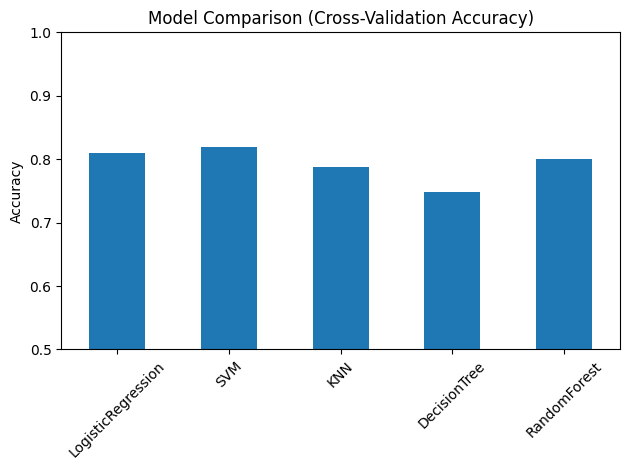

                    Accuracy Score
LogisticRegression        0.809927
SVM                       0.819707
KNN                       0.787514
DecisionTree              0.748624
RandomForest              0.799715


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn import svm
from sklearn.model_selection import KFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler


# LOAD DATA (Make sure adult.csv is in same folder)

df = pd.read_csv("adult.csv", na_values='?')


# CLEAN DATA

df = df.dropna()

# Target variable
Y = df['income'].map({'<=50K': 0, '>50K': 1})

# Features (only numeric for PCA)
X = df.drop('income', axis=1)
X = X.select_dtypes(include='number')


# SCALE DATA

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


# APPLY PCA (95% variance retained)

pca = PCA(n_components=0.95)
X_PCA = pca.fit_transform(X_scaled)

print("Shape after PCA:", X_PCA.shape)


# MODEL COMPARISON FUNCTION

def lets_try(train, labels):
    results = {}

    def test_model(model):
        cv = KFold(n_splits=5, shuffle=True, random_state=15)
        scores = cross_val_score(model, train, labels, cv=cv)
        return scores.mean()

    results["LogisticRegression"] = test_model(LogisticRegression(max_iter=1000))
    results["SVM"] = test_model(svm.SVC())
    results["KNN"] = test_model(KNeighborsClassifier(n_neighbors=3))
    results["DecisionTree"] = test_model(DecisionTreeClassifier())
    results["RandomForest"] = test_model(RandomForestClassifier())

    results_df = pd.DataFrame(results.values(), 
                              index=results.keys(), 
                              columns=["Accuracy Score"])

    # PLOT RESULTS

    plt.figure(figsize=(8,5))
    results_df.plot(kind="bar", legend=False)
    plt.title("Model Comparison (Cross-Validation Accuracy)")
    plt.ylim(0.5, 1)
    plt.ylabel("Accuracy")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    return results_df

# RUN MODEL COMPARISON

results = lets_try(X_PCA, Y)

print(results)
